# Parse Energies and Plot Relative Heatmap (Z×L)

This notebook scans subfolders named like `imidazol_z40_ser_L120` and builds a Z×L energy table:

- **Completion check**: the **penultimate** line of the `.out` file must contain `TELAPSE` (e.g., `TTTT... END         TELAPSE`). Otherwise that entry is `NaN`.
- Extract the last occurrence of **`TOTAL ENERGY + DISP + GCP (AU)`** and read the numeric value following it.
- Build a **Z×L** table (rows=Z, columns=L), then compute **relative energies** by subtracting the global minimum (ignoring NaNs).
- Plot a heatmap of relative energies.

**Folder name parsing rules** (per your spec):
- `z40` → **Z = 4.0** (no decimal → interpret as tenths)
- `L120` → **L = 12.0** (same tenths rule); `L127` → **12.7**

In [9]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [10]:
# --- Parameters ---
# Set the directory that CONTAINS your subfolders like: imidazol_z40_ser_L120, etc.

mode = 'ser'
ROOT = mode
cof = "COF-1"

# Optional range filters (set to None to disable a bound)
ZMIN = None   # e.g., 3.0
ZMAX = None   # e.g., 4.0
LMIN = None   # e.g., 0.0
LMAX = None   # e.g., 12.7

EH_TO_KJMOL = 2625.5

In [11]:
FOLDER_RE = re.compile(
    rf"^{re.escape(cof)}_z(?P<z>\d+(?:\.\d+)?)_{re.escape(mode)}_L(?P<L>\d+(?:\.\d+)?)$",
    re.IGNORECASE,
)

ENERGY_LABEL = "TOTAL ENERGY + DISP + GCP (AU)"
TELAPSE_TOKEN = "TELAPSE"  # must be present in the penultimate line

def parse_folder_name(name: str):
    m = FOLDER_RE.match(name)
    if not m:
        return None
    z_raw = m.group("z")
    L_raw = m.group("L")

    # Z: if no decimal (e.g., "40"), interpret as tenths -> 4.0
    if "." in z_raw:
        z = float(z_raw)
    else:
        z = float(int(z_raw)) / 10.0

    # L: tenths rule (e.g., "120" -> 12.0, "127" -> 12.7)
    if "." in L_raw:
        L = float(L_raw)
    else:
        L = float(int(L_raw)) / 10.0
    return z, L

def read_last_energy_if_complete(out_path: str):
    """
    Return the last 'TOTAL ENERGY + DISP + GCP (AU)' numeric value
    IF the penultimate line contains TELAPSE; else return np.nan.
    """
    try:
        with open(out_path, "r", errors="ignore") as f:
            lines = f.readlines()
    except Exception:
        return np.nan

    # Need at least 2 lines to check penultimate
    if len(lines) < 2:
        return np.nan
    if TELAPSE_TOKEN not in lines[-2]:
        return np.nan

    last_val = None
    num_re = re.compile(r"([-+]?(\d+(\.\d*)?|\.\d+)([eE][-+]?\d+)?)")

    # Iterate through lines and remember the last occurrence
    for i, line in enumerate(lines):
        if ENERGY_LABEL in line:
            tail = line.split(ENERGY_LABEL, 1)[1]
            m = num_re.search(tail)
            if m:
                last_val = float(m.group(1))
            else:
                # Try the next line if number isn't on the same line
                if i + 1 < len(lines):
                    m2 = num_re.search(lines[i + 1])
                    if m2:
                        last_val = float(m2.group(1))
    return last_val if last_val is not None else np.nan

def collect_energies(root: str, zmin: float=None, zmax: float=None, lmin: float=None, lmax: float=None):
    records = []
    for name in os.listdir(root):
        p = os.path.join(root, name)
        if not os.path.isdir(p):
            continue
        parsed = parse_folder_name(name)
        if not parsed:
            continue
        z, L = parsed

        if zmin is not None and z < zmin: 
            continue
        if zmax is not None and z > zmax: 
            continue
        if lmin is not None and L < lmin: 
            continue
        if lmax is not None and L > lmax: 
            continue

        outs = [os.path.join(p, f) for f in os.listdir(p) if f.lower().endswith(".out")]
        if not outs:
            energy = np.nan
        else:
            # If multiple .out files exist, pick the newest modified one
            outs.sort(key=lambda q: os.path.getmtime(q), reverse=True)
            energy = read_last_energy_if_complete(outs[0])

        records.append({"Z": z, "L": L, "energy": energy})

    if not records:
        return pd.DataFrame(columns=["Z", "L", "energy"]), pd.DataFrame()

    df = pd.DataFrame(records)
    df["Z"] = df["Z"].astype(float)
    df["L"] = df["L"].astype(float)

    z_sorted = sorted(df["Z"].unique())
    l_sorted = sorted(df["L"].unique())

    wide = df.pivot_table(index="Z", columns="L", values="energy", aggfunc="last").reindex(index=z_sorted, columns=l_sorted)
    return df, wide

def make_relative(wide: pd.DataFrame):
    vals = np.array(wide.values, dtype=float)
    mask = np.isfinite(vals)
    if not mask.any():
        return wide.copy(), math.nan, wide.copy()
    global_min = vals[mask].min()
    relative = (wide - global_min) * EH_TO_KJMOL
    return relative, global_min, wide

def plot_heatmap(df_rel: pd.DataFrame, out_png: str, title: str):
    plt.figure(figsize=(10, 6))
    data = df_rel.values

    # Plot the heatmap
    im = plt.imshow(data, aspect="auto", origin="lower")
    cbar = plt.colorbar(im, pad=0.02)
    cbar.set_label("Relative energy (kJ/mol)", labelpad=18, fontsize=12)

    # Tick labels
    plt.xticks(range(len(df_rel.columns)), [f"{c:.1f}" for c in df_rel.columns], rotation=45, ha="right", fontsize=10)
    plt.yticks(range(len(df_rel.index)), [f"{r:.1f}" for r in df_rel.index], fontsize=10)
    plt.xlabel("Inter Layer Slipping [Å]", fontsize=12)
    plt.ylabel("Inter Layer Distance [Å]", fontsize=12)
    plt.title(title, fontsize=14)

    # --- Highlight the minimum with a red square ---
    finite_vals = np.array(data, dtype=float)
    if np.isfinite(finite_vals).any():
        min_pos = np.unravel_index(np.nanargmin(finite_vals), finite_vals.shape)
        y, x = min_pos  # note: imshow uses (y,x)

        # Draw a red rectangle border around the minimum cell
        rect = patches.Rectangle(
            (x - 0.5, y - 0.5),  # bottom-left corner
            1, 1,                 # width, height
            linewidth=2.5,
            edgecolor='red',
            facecolor='none'
        )
        plt.gca().add_patch(rect)

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.show()

Mode = 'ser' → multiplying column 0.0 by 2
Saved: csv/energies_absolute_ser.csv, csv/energies_relative_ser.csv
Global minimum absolute energy (Eh): -2578.1668164417

Absolute energies (Eh):

Relative energies (kJ/mol):


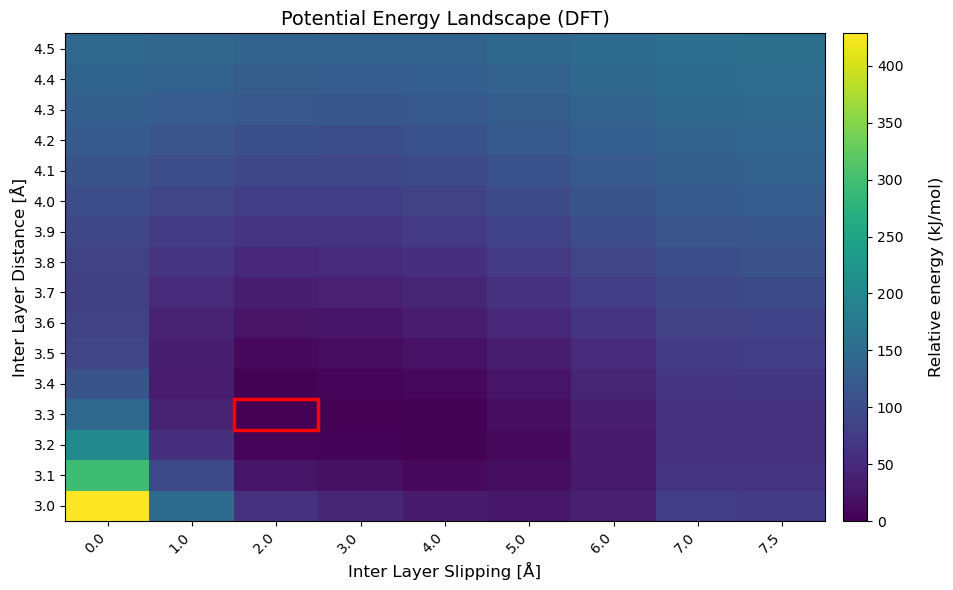

Saved heatmap: heatmap/heatmap_ser.png


In [12]:
# --- Run ---
df_long, df_abs = collect_energies(ROOT, ZMIN, ZMAX, LMIN, LMAX)

os.makedirs("csv", exist_ok=True)
os.makedirs("heatmap", exist_ok=True)

if df_abs.empty:
    print("No matching folders or no energies parsed. Check ROOT and folder naming.")
else:
    if mode.lower() == "ser" and not df_abs.empty:
        first_col = df_abs.columns[0]
        print(f"Mode = 'ser' → multiplying column {first_col} by 2")
        df_abs[first_col] = df_abs[first_col] * 2

    df_rel, global_min, df_abs_copy = make_relative(df_abs)

    # Save CSVs
    abs_csv = f"csv/energies_absolute_{mode}.csv"
    rel_csv = f"csv/energies_relative_{mode}.csv"
    df_abs.to_csv(abs_csv, float_format="%.12g")
    df_rel.to_csv(rel_csv, float_format="%.12g")
    print(f"Saved: {abs_csv}, {rel_csv}")
    print(f"Global minimum absolute energy (Eh): {global_min}")

    # Preview tables
    print("\nAbsolute energies (Eh):")
    # display(df_abs)

    print("\nRelative energies (kJ/mol):")
    # display(df_rel)

    # Plot heatmap
    png_path = f"heatmap/heatmap_{mode}.png"
    plot_heatmap(df_rel, png_path, title=f"Potential Energy Landscape (DFT)")
    print(f"Saved heatmap: {png_path}")